
# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [ ]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "example.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


In [ ]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


In [ ]:

import numpy as np

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    nir = dataset.read(4).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(3).astype(float)  # ช่อง Red (เช่น Band 3)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()



## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [ ]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [ ]:

from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "boundary.shp"  # ใส่ path ของไฟล์ขอบเขต
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


แบบฝึกหัด 1: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib

ดาวน์โหลดไฟล์เสร็จแล้ว
Width: 791
Height: 718
CRS: EPSG:32618
Bounds: BoundingBox(left=101985.0, bottom=2611485.0, right=339315.0, top=2826915.0)
Band count: 3


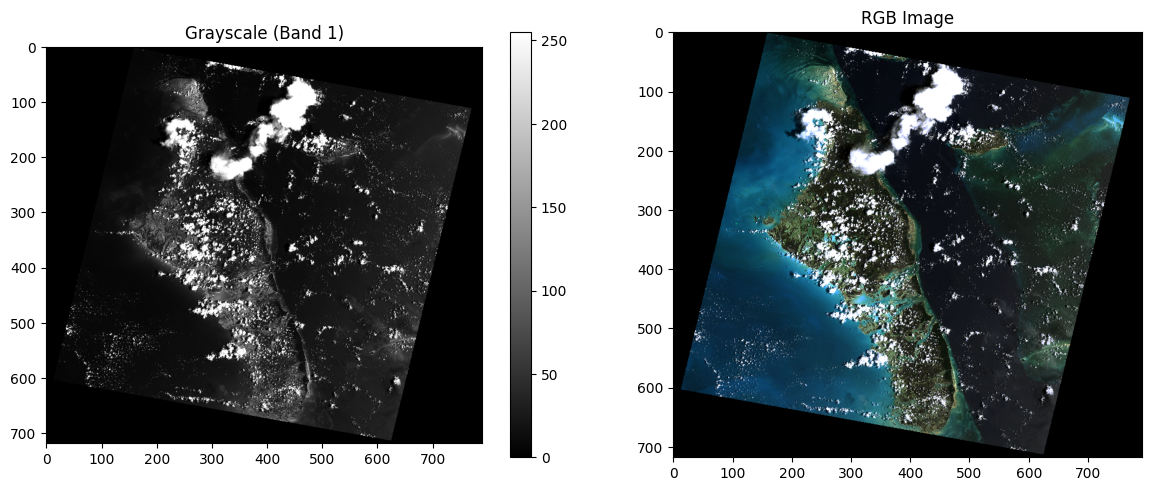

In [10]:
# pip install rasterio matplotlib requests

import rasterio
import matplotlib.pyplot as plt
import numpy as np
import requests


url = "https://github.com/mapbox/rasterio/raw/main/tests/data/RGB.byte.tif"
file_name = "RGB.byte.tif"

# โหลดไฟล์
response = requests.get(url)
with open(file_name, "wb") as f:
    f.write(response.content)

print("ดาวน์โหลดไฟล์เสร็จแล้ว")


with rasterio.open(file_name) as src:
    print("Width:", src.width)
    print("Height:", src.height)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Band count:", src.count)

    band1 = src.read(1)

    if src.count >= 3:
        r = src.read(1)
        g = src.read(2)
        b = src.read(3)
        rgb = np.dstack((r, g, b))


plt.figure(figsize=(12, 5))

# ขาวดำ
plt.subplot(1, 2, 1)
plt.imshow(band1, cmap='gray')
plt.title("Grayscale (Band 1)")
plt.colorbar()

# สี
if 'rgb' in locals():
    plt.subplot(1, 2, 2)
    plt.imshow(rgb)
    plt.title("RGB Image")

plt.tight_layout()
plt.show()

แบบฝึกหัด 2: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

In [11]:

import rasterio

raster_path = "RGB.byte.tif"

with rasterio.open(raster_path) as src:
    print("Driver:", src.driver)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Count (Bands):", src.count)
    print("CRS:", src.crs)
    print("Transform:", src.transform)
    print("Bounds:", src.bounds)
    print("Dtype:", src.dtypes)
    print("NoData Value:", src.nodata)

Driver: GTiff
Width: 791
Height: 718
Count (Bands): 3
CRS: EPSG:32618
Transform: | 300.04, 0.00, 101985.00|
| 0.00,-300.04, 2826915.00|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=101985.0, bottom=2611485.0, right=339315.0, top=2826915.0)
Dtype: ('uint8', 'uint8', 'uint8')
NoData Value: 0.0


แบบฝึกหัด 3: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่

Band count: 3


/tmp/ipykernel_10295/3190732051.py:15: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir - red) / (nir + red)


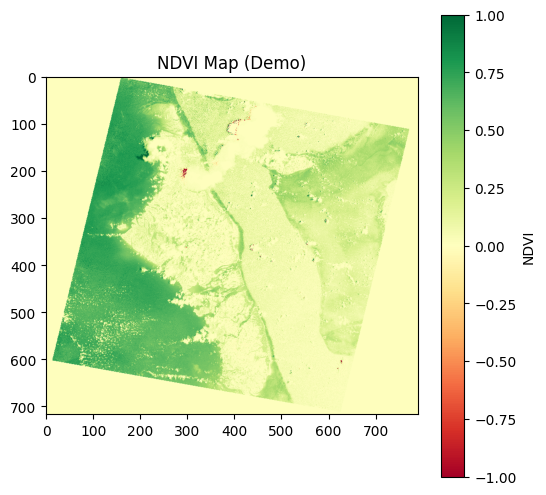

In [14]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

raster_path = "RGB.byte.tif"

with rasterio.open(raster_path) as src:
    print("Band count:", src.count)

    # ใช้ band ที่มีอยู่ (จำลอง)
    red = src.read(1).astype('float32')   # สมมติเป็น Red
    nir = src.read(2).astype('float32')   # สมมติเป็น NIR


ndvi = (nir - red) / (nir + red)

# กันหาร 0
ndvi = np.where((nir + red) == 0, 0, ndvi)


plt.figure(figsize=(6,6))
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar(label="NDVI")
plt.title("NDVI Map (Demo)")
plt.show()

แบบฝึกหัด 4: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

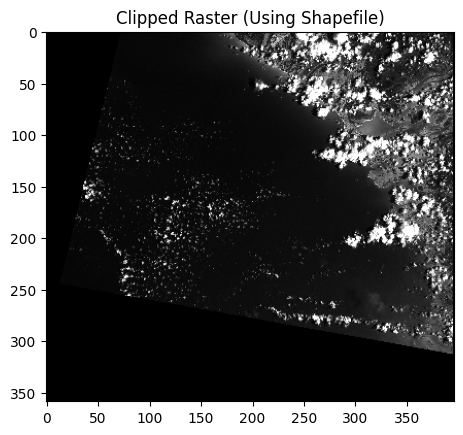

In [18]:
# pip install rasterio geopandas shapely matplotlib

import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt


raster_path = "RGB.byte.tif"

with rasterio.open(raster_path) as src:
    bounds = src.bounds
    minx, miny, maxx, maxy = bounds


    polygon = box(minx, miny, (minx+maxx)/2, (miny+maxy)/2)


    gdf = gpd.GeoDataFrame({'geometry': [polygon]}, crs=src.crs)
    gdf.to_file("clip_area.shp")

gdf = gpd.read_file("clip_area.shp")


with rasterio.open(raster_path) as src:
    gdf = gdf.to_crs(src.crs)
    out_image, out_transform = mask(src, gdf.geometry, crop=True)

plt.imshow(out_image[0], cmap='gray')
plt.title("Clipped Raster (Using Shapefile)")
plt.show()